In [2]:
import sys
sys.path.append("..")

from utils import read_data

In [3]:
from utils import read_data

DF_FOLDER_PATH = "../../code snippets-with-labels&metrics"
GRANULARITIES = ['file', 'class', 'method', 'block']

# got this list ffrom the authors github repository
PROJECTS = [
    "antlr4-4.11.0", "dbeaver-22.2.5", "elasticsearch-8.5.2", "exoplayer-2.18.2",
    "fastjson-1.2.83", "flink-1.15.3", "guava-31.1", "jenkins-2.379", "libgdx-1.11.0", 
    "logstash-8.5.2", "mockito-4.9.0", "openrefine-3.6.2", "presto-0.278", 
    "quarkus-2.14.0", "questdb-6.6", "redisson-3.18.1", "rxjava-3.1.5", "tink-1.7.0"
]

data = read_data(GRANULARITIES=GRANULARITIES, DF_FOLDER_PATH = DF_FOLDER_PATH, PROJECTS = PROJECTS)

100%|██████████| 4/4 [00:06<00:00,  1.65s/it]


In [4]:
data, GRANULARITIES, PROJECTS

sys.path.append("../..")
from project_Info import file_feature_names_lowercase, class_feature_names_lowercase, method_feature_names_lowercase, block_feature_names_lowercase 

features = {
    "file": file_feature_names_lowercase,
    "class": class_feature_names_lowercase,
    "method": method_feature_names_lowercase,
    "block": block_feature_names_lowercase
}

In [5]:
def ten_folds(df, granularity, k_fold = 10):
    df.columns = df.columns.str.lower()

    # 1. Separate your features (X) from your target variable (y)
    X = df[features[granularity]]
    y = df['CommentsAssociatedLabel'.lower()]

    skf = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=RANDOM_STATE)

    f1_scores = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=12, n_estimators=500, learning_rate=0.05, verbose=-1)
        tech = ASMOTE(random_state=RANDOM_STATE, clf=LGBMClassifier(random_state=RANDOM_STATE))
        
        X_train_resample, y_train_resample = tech.fit_resample(X_train, y_train)

        model.fit(X_train_resample, y_train_resample)

        # predict
        y_pred = model.predict(X_test)
        # y_pred_prob = model.predict_proba(X_test)[:, 1]

        f1 = f1_score(y_test, y_pred)

        f1_scores.append(f1)

    mean_f1_score = sum(f1_scores) / k_fold

    return mean_f1_score



In [6]:
X_ = [1,2,3,4,5,1,2]

len(X_) - len(set(X_))

2

In [7]:
data["file"]["antlr4"].columns

Index(['ID', 'FilePath', 'ClassName', 'MethodName', 'Content', 'CommentFor',
       'CommentsIn', 'CommentsAssociated', 'StartLine', 'EndLine',
       'eachLabelCommentFor', 'CommentForLabel', 'eachLabelCommentsIn',
       'CommentsInLabel', 'eachLabelCommentsAssociated',
       'CommentsAssociatedLabel', 'PseudoLabelForCASFromMAT',
       'PseudoLabelForCASFromGGSATD', 'PseudoLabelForCASFromXGBoost', 'class',
       'type', 'cbo', 'cboModified', 'fanin', 'fanout', 'wmc', 'dit', 'noc',
       'rfc', 'lcom', 'lcom*', 'tcc', 'lcc', 'totalMethodsQty',
       'staticMethodsQty', 'publicMethodsQty', 'privateMethodsQty',
       'protectedMethodsQty', 'defaultMethodsQty', 'visibleMethodsQty',
       'abstractMethodsQty', 'finalMethodsQty', 'synchronizedMethodsQty',
       'totalFieldsQty', 'staticFieldsQty', 'publicFieldsQty',
       'privateFieldsQty', 'protectedFieldsQty', 'defaultFieldsQty',
       'finalFieldsQty', 'synchronizedFieldsQty', 'nosi', 'loc', 'returnQty',
       'loopQty', 'co

In [8]:
# Verifying the presence of duplicates by project using everything

from tqdm import tqdm


diff_by_project = {} 

project_with_duplicates_count = 0
for granularity in tqdm(GRANULARITIES, desc="Granularities"):
    diff_by_project[granularity] = {}
    for project in tqdm(data[granularity].keys(), desc=f"Projects ({granularity})", leave=False):
        df = data[granularity][project]
        df.columns = [column.lower() for column in df.columns]

        X = df[features[granularity] + ["content"] + ["classname"] + ["filepath"]]
        # X = df[data[granularity]["antlr4"].columns]
        # y = df['CommentsAssociatedLabel'.lower()]

        # diff = len(X) - len(set(X))
        dups = X.duplicated().sum()

        diff_by_project[granularity][project] = {"duplicate_count": dups, "length": len(X)} 

        if dups > 0: 
            print(f"{dups} out of {len(X)} are duplicates on the project {project} on the granularity {granularity}")
            project_with_duplicates_count += 1

print()
print(f"{project_with_duplicates_count} out of {18 * 4} projects have at least one duplicate")


Granularities: 100%|██████████| 4/4 [00:01<00:00,  2.69it/s]

58 out of 1122 are duplicates on the project antlr4 on the granularity block
70 out of 5042 are duplicates on the project dbeaver on the granularity block
1272 out of 22336 are duplicates on the project elasticsearch on the granularity block
1856 out of 10897 are duplicates on the project exoplayer on the granularity block
274 out of 1327 are duplicates on the project fastjson on the granularity block
1732 out of 22053 are duplicates on the project flink on the granularity block
438 out of 8262 are duplicates on the project guava on the granularity block
188 out of 4354 are duplicates on the project jenkins on the granularity block
182 out of 2860 are duplicates on the project libgdx on the granularity block
40 out of 566 are duplicates on the project logstash on the granularity block
348 out of 1816 are duplicates on the project mockito on the granularity block
54 out of 1081 are duplicates on the project openrefine on the granularity block
544 out of 12178 are duplicates on the proje

In [22]:
# Verifying the presence of duplicates by project considering only the metrics (the independent variables)

from tqdm import tqdm


diff_by_project = {} 

project_with_duplicates_count = 0
for granularity in tqdm(GRANULARITIES, desc="Granularities"):
    diff_by_project[granularity] = {}
    for project in tqdm(data[granularity].keys(), desc=f"Projects ({granularity})", leave=False):
        df = data[granularity][project]
        df.columns = [column.lower() for column in df.columns]

        X = df[features[granularity]]
        Y = df['CommentsAssociatedLabel'.lower()]

        # diff = len(X) - len(set(X))
        dups = X.duplicated().sum()

        diff_by_project[granularity][project] = {"duplicate_count": dups, "length": len(X), "X": X, "Y": Y} 

        if dups > 0: 
            print(f"{dups} out of {len(X)} are duplicates")
            project_with_duplicates_count += 1

print()
print(f"{project_with_duplicates_count} out of {18 * 4} projects have at least one duplicate")


Granularities:   0%|          | 0/4 [00:00<?, ?it/s]

34 out of 507 are duplicates
164 out of 4726 are duplicates
612 out of 14066 are duplicates
3 out of 1399 are duplicates
51 out of 1051 are duplicates
310 out of 13075 are duplicates
20 out of 1498 are duplicates
14 out of 1624 are duplicates
169 out of 2198 are duplicates
21 out of 505 are duplicates
14 out of 897 are duplicates
53 out of 935 are duplicates
284 out of 7877 are duplicates
215 out of 5668 are duplicates
319 out of 2453 are duplicates
77 out of 1378 are duplicates
94 out of 1857 are duplicates
11 out of 631 are duplicates


Granularities:  50%|█████     | 2/4 [00:00<00:00, 16.55it/s]

17 out of 428 are duplicates
97 out of 3999 are duplicates
239 out of 10825 are duplicates
18 out of 2158 are duplicates
62 out of 1118 are duplicates
771 out of 16473 are duplicates
63 out of 2313 are duplicates
16 out of 2142 are duplicates
105 out of 2143 are duplicates
14 out of 446 are duplicates
7 out of 656 are duplicates
4 out of 554 are duplicates
23 out of 3675 are duplicates
272 out of 6412 are duplicates
21 out of 1036 are duplicates
59 out of 1220 are duplicates
47 out of 1162 are duplicates
23 out of 737 are duplicates


87 out of 1283 are duplicates
604 out of 5565 are duplicates
5367 out of 27447 are duplicates
1299 out of 10562 are duplicates
352 out of 1287 are duplicates
5091 out of 28092 are duplicates
1295 out of 8344 are duplicates
443 out of 6637 are duplicates
1719 out of 7282 are duplicates
35 out of 809 are duplicates
178 out of 1632 are duplicates
68 out of 1328 are duplicates
675 out of 8423 are duplicates
2769 out of 11355 are duplicates
315 out of 3202 are duplicates
3354 out of 4790 are duplicates
605 out of 3858 are duplicates
170 out of 2038 are duplicates


473 out of 1122 are duplicates
1550 out of 5042 are duplicates
11197 out of 22336 are duplicates
6857 out of 10897 are duplicates
781 out of 1327 are duplicates
12452 out of 22053 are duplicates
6230 out of 8262 are duplicates
2202 out of 4354 are duplicates
1475 out of 2860 are duplicates
204 out of 566 are duplicates
1226 out of 1816 are duplicates
347 out of 1081 are duplicates
6896 out of 12178 are duplicates
4242 out of 8580 are duplicates
1716 out of 4162 are duplicates


Granularities: 100%|██████████| 4/4 [00:00<00:00, 14.01it/s]

301 out of 589 are duplicates
1492 out of 2162 are duplicates
1161 out of 1769 are duplicates

72 out of 72 projects have at least one duplicate


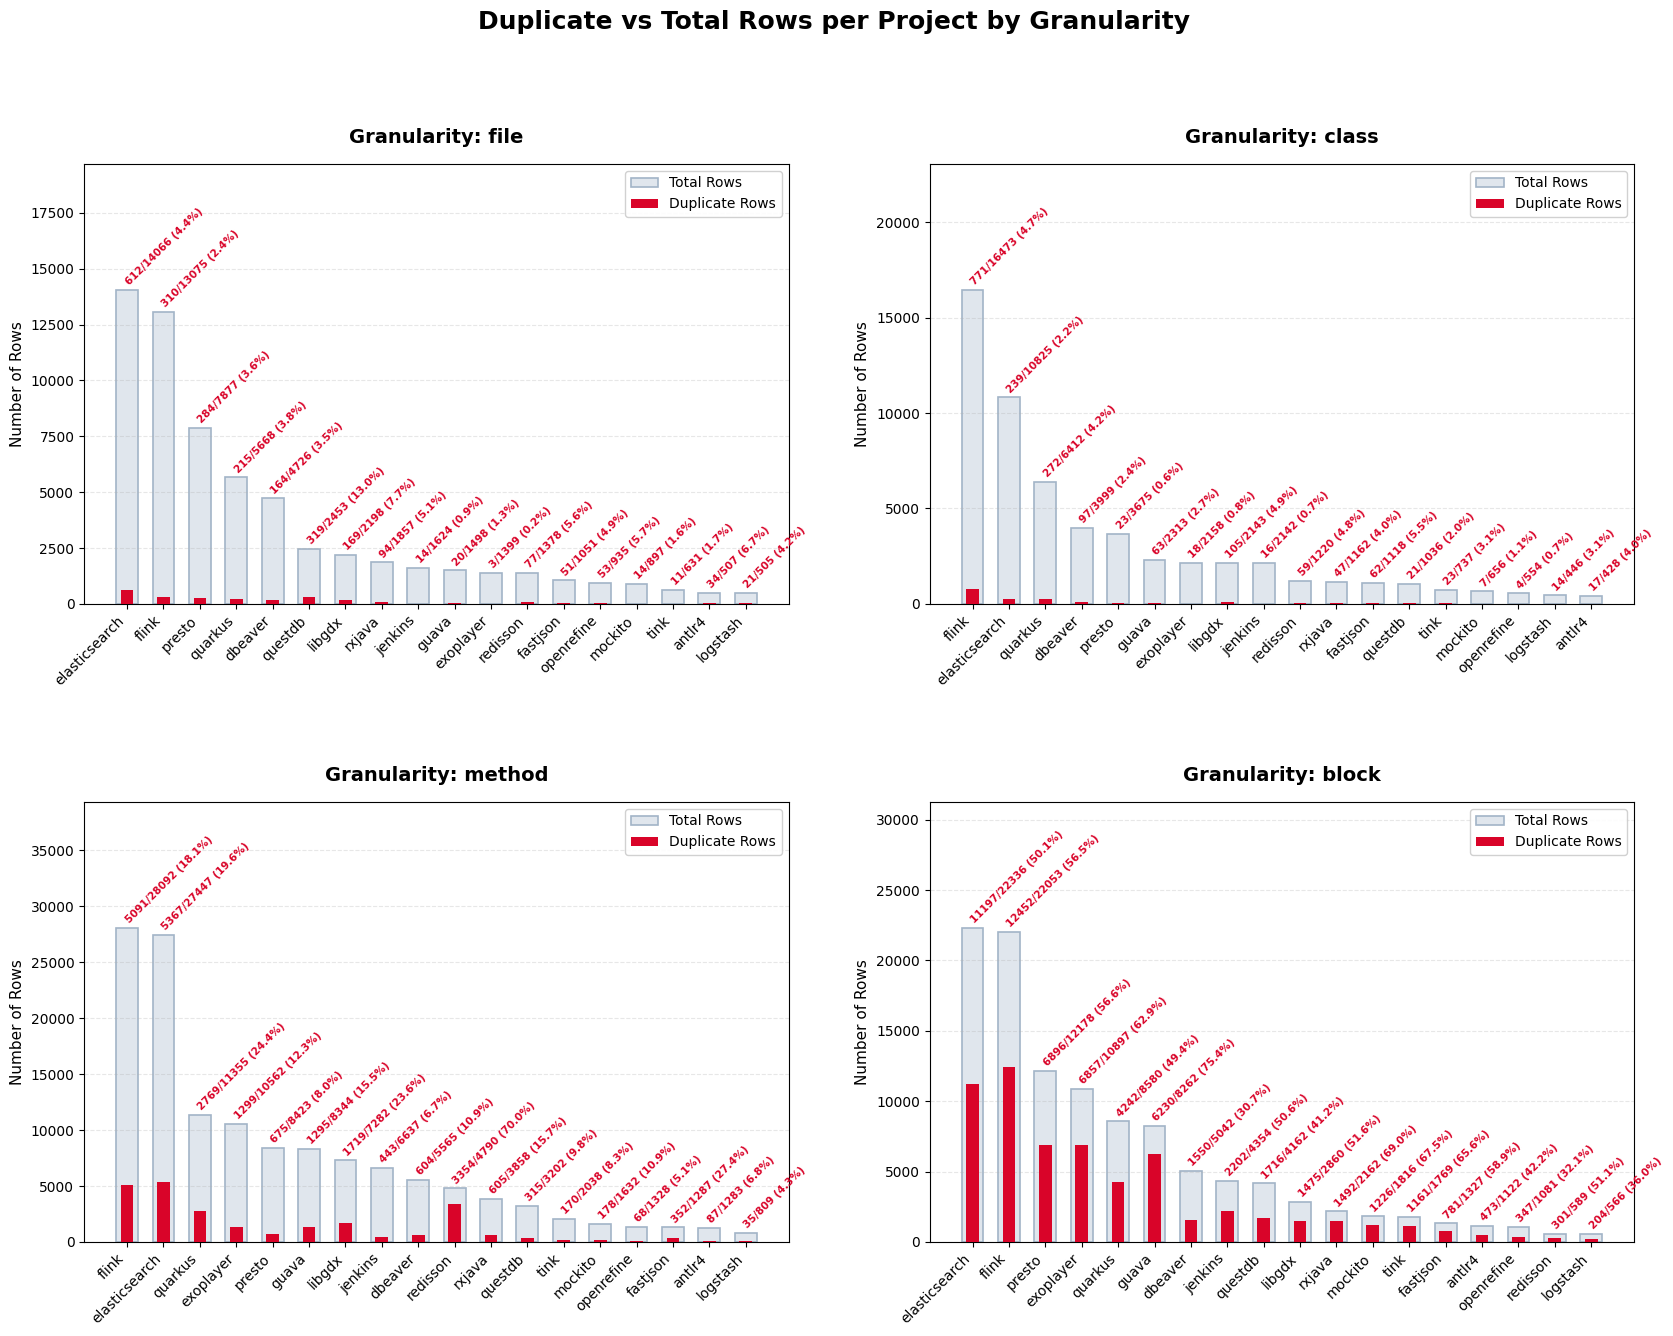

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare summary DataFrame
records = []
for granularity, projects in diff_by_project.items():
    for project, values in projects.items():
        total = values["length"]
        dups = values["duplicate_count"]
        pct_dup = (dups / total * 100) if total > 0 else 0

        records.append({
            "Granularity": granularity,
            "Project": project,
            "Total": total,
            "Duplicates": dups,
            "Pct_Duplicates": pct_dup
        })

df_summary = pd.DataFrame(records)

# 2. Setup Figure
granularities = df_summary["Granularity"].unique()
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

color_total = "#e0e6ed"
color_total_edge = "#a2b4c7"
color_dup = "#d90429"

for i, gran in enumerate(granularities):
    ax = axes[i]
    sub_df = df_summary[df_summary["Granularity"] == gran].sort_values(
        by="Total", ascending=False
    )

    x_positions = range(len(sub_df))

    # Outer bar (Total)
    bars_total = ax.bar(
        x_positions, sub_df["Total"], width=0.6, 
        color=color_total, edgecolor=color_total_edge, linewidth=1.2, label="Total Rows"
    )

    # Inner sub-bar (Duplicates)
    bars_dup = ax.bar(
        x_positions, sub_df["Duplicates"], width=0.35, 
        color=color_dup, label="Duplicate Rows", zorder=3
    )

    # Annotations - VERTICAL ROTATION FIX
    max_height = sub_df["Total"].max()
    for bar_t, (_, row) in zip(bars_total, sub_df.iterrows()):
        total_val = row["Total"]
        dup_val = row["Duplicates"]
        pct = row["Pct_Duplicates"]

        label_text = f"{dup_val}/{total_val} ({pct:.1f}%)" if dup_val > 0 else f"0/{total_val}"

        # Rotate text 90 degrees vertically so it never collides horizontally
        ax.text(
            bar_t.get_x() + bar_t.get_width() / 2.0,
            bar_t.get_height() + (max_height * 0.02),
            label_text,
            ha="left",             # Aligns baseline to the bar center
            va="center",
            rotation=45,           # Vertical text!
            rotation_mode="anchor",
            fontsize=7.5,
            fontweight="bold",
            color="#2b2b2b" if dup_val == 0 else color_dup,
        )

    ax.set_title(f"Granularity: {gran}", fontsize=14, fontweight="bold", pad=15)
    ax.set_ylabel("Number of Rows", fontsize=11)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(sub_df["Project"], rotation=45, ha="right", fontsize=10)
    ax.legend(loc="upper right", framealpha=0.9, fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

    # 40% vertical padding so rotated labels don't get cut off at the top border
    ax.set_ylim(0, max_height * 1.40)

plt.suptitle("Duplicate vs Total Rows per Project by Granularity", fontsize=18, fontweight="bold", y=0.99)
plt.subplots_adjust(hspace=0.45, wspace=0.2)
plt.show()

In [12]:
X.duplicated()[0:20]

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12     True
13     True
14    False
15    False
16    False
17     True
18    False
19     True
dtype: bool

In [17]:
diff_by_project["file"]

{'antlr4': {'duplicate_count': np.int64(34), 'length': 507},
 'dbeaver': {'duplicate_count': np.int64(164), 'length': 4726},
 'elasticsearch': {'duplicate_count': np.int64(612), 'length': 14066},
 'exoplayer': {'duplicate_count': np.int64(3), 'length': 1399},
 'fastjson': {'duplicate_count': np.int64(51), 'length': 1051},
 'flink': {'duplicate_count': np.int64(310), 'length': 13075},
 'guava': {'duplicate_count': np.int64(20), 'length': 1498},
 'jenkins': {'duplicate_count': np.int64(14), 'length': 1624},
 'libgdx': {'duplicate_count': np.int64(169), 'length': 2198},
 'logstash': {'duplicate_count': np.int64(21), 'length': 505},
 'mockito': {'duplicate_count': np.int64(14), 'length': 897},
 'openrefine': {'duplicate_count': np.int64(53), 'length': 935},
 'presto': {'duplicate_count': np.int64(284), 'length': 7877},
 'quarkus': {'duplicate_count': np.int64(215), 'length': 5668},
 'questdb': {'duplicate_count': np.int64(319), 'length': 2453},
 'redisson': {'duplicate_count': np.int64(77)

In [27]:
diff_by_project['file']['antlr4']["X"].iterrows

<bound method DataFrame.iterrows of      cbo  cbomodified  fanin  fanout  dit  noc  lcc  lcom     lcom*  tcc  ...  \
0      6            7      1       6    1    0  0.0     0  0.083333  0.0  ...   
1     24           26      2      24    5    0  0.0    35  0.850202  0.0  ...   
2      9           11      2       9    1    0  0.0    38  0.725275  0.0  ...   
3      1            4      3       1    1    0  0.0     1  0.000000  0.0  ...   
4     16           17      1      16    2    0  0.0     0  0.700000  0.0  ...   
..   ...          ...    ...     ...  ...  ...  ...   ...       ...  ...  ...   
502    6            9      3       6    4    0  0.0    15  0.000000  0.0  ...   
503    5            7      2       5    3    0  0.0     6  0.000000  0.0  ...   
504    6            8      2       6    3    0  0.0     4  0.400000  0.0  ...   
505    5           16     11       5    4    0  0.0    15  0.000000  0.0  ...   
506    4            5      1       4    1    0  0.0   153  0.000000  0.0 

In [40]:
repeated_x_to_label = {}

for granularity in tqdm(GRANULARITIES):
    repeated_x_to_label[granularity] = {}
    for project in PROJECTS:
        repeated_x_to_label[granularity][project] = {}
        X = [row for row in diff_by_project[granularity][project.split("-")[0]]["X"].iterrows()]
        Y =  list(diff_by_project[granularity][project.split("-")[0]]["Y"])

        for i in range(len(X)):
            x_ = X[i]
            y_ = Y[i]
            
            if not hash(str(x_)) in repeated_x_to_label[granularity][project].keys():
                repeated_x_to_label[granularity][project][hash(str(x_))] = []

            repeated_x_to_label[granularity][project][hash(str(x_))].append(y_)

  0%|          | 0/4 [00:42<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
repeated_x_to_label

In [41]:
from tqdm import tqdm

repeated_x_to_label = {}

for granularity in tqdm(GRANULARITIES):
    repeated_x_to_label[granularity] = {}
    for project in PROJECTS:
        proj_key = project.split("-")[0]
        
        # Pull X (DataFrame) and Y (Series/List)
        df_x = diff_by_project[granularity][proj_key]["X"].copy()
        df_x["_y_label"] = diff_by_project[granularity][proj_key]["Y"]

        # Group by all feature columns and collect labels into lists
        feature_cols = [c for c in df_x.columns if c != "_y_label"]
        grouped = df_x.groupby(feature_cols)["_y_label"].apply(list)

        # Map back to standard dict
        repeated_x_to_label[granularity][project] = grouped.to_dict()

100%|██████████| 4/4 [00:03<00:00,  1.17it/s]


In [50]:
ex = repeated_x_to_label["file"]["antlr4-4.11.0"].keys()


In [51]:
ex

dict_keys([(0, 0, 0, 0, 1, 0, 0.0, 0, 0.0, 0.0, 0, 1, 0, 6, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 38, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0), (0, 0, 0, 0, 1, 0, 0.0, 0, 0.0, 0.0, 4, 3, 2, 19, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 36, 2, 1, 0, 0, 0, 0, 0, 6, 2, 0, 0, 0, 2), (0, 0, 0, 0, 4, 0, -1.0, 0, 0.0, -1.0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 23, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0), (0, 1, 1, 0, 1, 0, -1.0, 0, 0.0, -1.0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0), (0, 1, 1, 0, 2, 0, 0.0, 0, 0.0, 0.0, 27, 9, 5, 67, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 129, 17, 2, 0, 0, 10, 8, 4, 4, 17, 0, 0, 2, 0), (0, 1, 1, 0, 5, 0, 0.0, 1, 0.0, 0.0, 5, 4, 2, 15, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 18, 2, 2, 1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0), (0, 1, 1, 0, 6, 0, 0.0, 6, 0.0, 0.0, 1, 4,

In [38]:
hash(str(X[i]))

4450173458156970094

In [32]:
repeated_x_to_label[granularity][project]

{}

In [24]:
X[0]

'annotationqty'

In [11]:
diff_by_project

{'file': {'antlr4': {'duplicate_count': np.int64(34), 'length': 507},
  'dbeaver': {'duplicate_count': np.int64(164), 'length': 4726},
  'elasticsearch': {'duplicate_count': np.int64(612), 'length': 14066},
  'exoplayer': {'duplicate_count': np.int64(3), 'length': 1399},
  'fastjson': {'duplicate_count': np.int64(51), 'length': 1051},
  'flink': {'duplicate_count': np.int64(310), 'length': 13075},
  'guava': {'duplicate_count': np.int64(20), 'length': 1498},
  'jenkins': {'duplicate_count': np.int64(14), 'length': 1624},
  'libgdx': {'duplicate_count': np.int64(169), 'length': 2198},
  'logstash': {'duplicate_count': np.int64(21), 'length': 505},
  'mockito': {'duplicate_count': np.int64(14), 'length': 897},
  'openrefine': {'duplicate_count': np.int64(53), 'length': 935},
  'presto': {'duplicate_count': np.int64(284), 'length': 7877},
  'quarkus': {'duplicate_count': np.int64(215), 'length': 5668},
  'questdb': {'duplicate_count': np.int64(319), 'length': 2453},
  'redisson': {'duplic